In [1]:
import os
import sys
import h5py
import yaml
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

import snntorch
from snntorch import spikegen

import seaborn as sns
from matplotlib import pyplot as plt
import colorsys
import matplotlib
from matplotlib.lines import Line2D
from matplotlib.font_manager import FontProperties

labelfont = FontProperties()
labelfont.set_family('serif')
labelfont.set_name('Times New Roman')
labelfont.set_size(14)

axislabelfont = FontProperties()
axislabelfont.set_family('serif')
axislabelfont.set_name('Times New Roman')
axislabelfont.set_size(22)

tickfont = FontProperties()
tickfont.set_family('serif')
tickfont.set_name('Times New Roman')
tickfont.set_size(16)

axisfontsize = 16
labelfontsize = 16

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.default"] = "rm"
plt.rcParams['text.usetex'] = True

In [2]:
from snnae import SNNAE, AE
from data_utils import get_cms_data, get_top_data, plot_cms_data
from dataset import cdataset

# CMS data

In [3]:
data = get_cms_data( num_events_per_class=100000, add_one_hot=False, drop_angles=True, pt_norm_method="max_per_category", pt_offset=0.1 )

sm data shape before any preprocessing: (100000, 19, 3)
sm data shape after dropping angles: (100000, 19, 1)
sm data shape after flattening: (100000, 19)


In [4]:
sm_dataset = cdataset( data["sm"], labels=np.zeros( data["sm"].shape[0] ) )
h0_dataset = cdataset( np.concatenate( [data["sm"],data["h0"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["h0"].shape[0])] ) )
hc_dataset = cdataset( np.concatenate( [data["sm"],data["hc"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["hc"].shape[0])] ) )
a4l_dataset = cdataset( np.concatenate( [data["sm"],data["a4l"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["a4l"].shape[0])] ) )
lq_dataset = cdataset( np.concatenate( [data["sm"],data["lq"]], axis=0 ), labels=np.concatenate( [np.zeros(data["sm"].shape[0]),np.ones(data["lq"].shape[0])] ) )

batch_size = 1000

train_loader = DataLoader( sm_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_h0 = DataLoader( h0_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_hc = DataLoader( hc_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_a4l = DataLoader( a4l_dataset, batch_size=batch_size, shuffle=True, drop_last=True )
test_loader_lq = DataLoader( lq_dataset, batch_size=batch_size, shuffle=True, drop_last=True )

train_loader_ns = DataLoader( sm_dataset, batch_size=batch_size, shuffle=False, drop_last=False )
test_loader_h0_ns = DataLoader( h0_dataset, batch_size=batch_size, shuffle=False, drop_last=False )
test_loader_hc_ns = DataLoader( hc_dataset, batch_size=batch_size, shuffle=False, drop_last=False )
test_loader_a4l_ns = DataLoader( a4l_dataset, batch_size=batch_size, shuffle=False, drop_last=False )
test_loader_lq_ns = DataLoader( lq_dataset, batch_size=batch_size, shuffle=False, drop_last=False )

In [5]:
#plot_cms_data()

In [6]:
def full_snn_run( run_name, input_dim, beta, thresh, num_steps, layers, latent_dim, lr, num_epochs, quant, qpr, num_nets ):
    os.mkdir(run_name)
    save_args = {    "input_dim":input_dim,
                "beta":beta,
                "thresh":thresh,
                "num_steps":num_steps,
                "layers":layers,
                "latent_dim":latent_dim,
                "lr":lr,
                "num_epochs":num_epochs,
                "quant":quant,
                "qpr": qpr,
                "num_nets":num_nets
           }
    with open( run_name + '/args.yaml', 'w' ) as f:
        yaml.dump(save_args, f, default_flow_style=False)
    run_args = {    "input_dim":input_dim,
                "beta":beta,
                "thresh":thresh,
                "num_steps":num_steps,
                "layers":layers,
                "latent_dim":latent_dim,
                "lr":lr,
                "quant":quant,
                "qpr": qpr,
           }
    labels = {"A4l":'$A_{4l}$',"h0":'$h_0$',"hc":'$h_+$',"LQ":'$\phi$'}
    colors = {"A4l":'b',"h0":'r',"hc":'g',"LQ":'m'}
    sig_loaders = {"A4l":test_loader_a4l,"h0":test_loader_h0,"hc":test_loader_hc,"LQ":test_loader_lq}
    all_sparsity = []
    all_tpr = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    all_inv_fpr = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    all_auc = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    auc_mean = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    auc_std = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    all_inv_fpr_at_0_3 = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    inv_fpr_at_0_3_mean = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    inv_fpr_at_0_3_std = {"A4l":[],"h0":[],"hc":[],"LQ":[]}
    final_losses = []
    for i in range(num_nets):
        print( f'-- NET {i} --') 
        net = SNNAE( **run_args )
        net.train_model( train_loader, num_epochs=num_epochs )
        all_sparsity.append( net.eval_sparsity(train_loader) )
        for sig in ["A4l","h0","hc","LQ"]:
            tpr, inv_fpr, roc_auc, inv_fpr_at_0_3 = net.eval_model(sig_loaders[sig])
            all_tpr[sig].append(tpr)
            all_inv_fpr[sig].append(inv_fpr)
            all_auc[sig].append(roc_auc)
            all_inv_fpr_at_0_3[sig].append(inv_fpr_at_0_3)
        net.plot_loss_epochs( log_yscale=True, savefig=run_name+f"/net_{i}_loss_curve.png", show_plots=False)
        final_losses.append( net.loss_hist[-1] )
        loaders = [train_loader, test_loader_a4l, test_loader_h0, test_loader_hc, test_loader_lq]
        lsp_labels =  ["SM", "$h_0$", "$h_+$", "$A_{4l}$", "$\phi$"]
        #lsp_xlabels = [ '', '', '$D_{0,t}$', '', '', '', '', '$D_{1,t}$', '', '', '', '', '$D_{2,t}$', '', '', '', '','', '', '$D_{3,t}$', '', '' ]
        lsp_xlabels = [ '', '','', '','', '$D_{0,t}$','', '', '', '', '', '','', '','', '$D_{1,t}$','', '', '', '', '', '','', '','', '$D_{2,t}$','', '', '', '', '', '','', '','', '$D_{3,t}$','', '', '', '','', '','', '','', '$D_{4,t}$','', '', '', '', '', '','', '','', '$D_{5,t}$','', '', '', '', '', '','', '','', '$D_{6,t}$','', '', '', '', '', '','', '','', '$D_{7,t}$','', '', '', '' ]
        net.plot_latent_space_reps( [loaders[0]], [lsp_labels[0]], xlabels=lsp_xlabels, savefig=run_name+f"/net_{i}_latent_space_reps_sm.png", show_plots=False)
        net.plot_latent_space_reps( [loaders[1]], [lsp_labels[1]], xlabels=lsp_xlabels, savefig=run_name+f"/net_{i}_latent_space_reps_h0.png", show_plots=False)
        net.plot_latent_space_reps( [loaders[2]], [lsp_labels[2]], xlabels=lsp_xlabels, savefig=run_name+f"/net_{i}_latent_space_reps_hc.png", show_plots=False)
        net.plot_latent_space_reps( [loaders[3]], [lsp_labels[3]], xlabels=lsp_xlabels, savefig=run_name+f"/net_{i}_latent_space_reps_a4l.png", show_plots=False)
        net.plot_latent_space_reps( [loaders[4]], [lsp_labels[4]], xlabels=lsp_xlabels, savefig=run_name+f"/net_{i}_latent_space_reps_lq.png", show_plots=False)
        with open( run_name+f'/net_{i}_losses.txt', 'w' ) as f:
            f.write( str([ i for i in net.loss_hist ]) )
    sparsity_mean = np.mean(all_sparsity)
    sparsity_std = np.std(all_sparsity)
    plt.clf()
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_box_aspect(1)
    target_tprs = np.linspace(0, 1, 100)
    for sig in ["A4l","h0","hc","LQ"]:
        collected_inv_fprs = []
        auc_mean[sig] = np.mean(all_auc[sig])
        auc_std[sig] = np.std(all_auc[sig])
        inv_fpr_at_0_3_mean[sig] = np.mean(all_inv_fpr_at_0_3[sig])
        inv_fpr_at_0_3_std[sig] = np.std(all_inv_fpr_at_0_3[sig])
        for target in target_tprs:
            inv_fprs_at_target = []
            for tpr, inv_fpr in zip(all_tpr[sig], all_inv_fpr[sig]):
                if len(tpr) == 0:
                    continue
                idx = np.argmin(np.abs(tpr - target))  # Index of closest TPR
                inv_fprs_at_target.append(inv_fpr[idx])
            collected_inv_fprs.append(inv_fprs_at_target)
        collected_inv_fprs = np.array(collected_inv_fprs, dtype=float)
        mean_inv_fpr = np.mean(collected_inv_fprs, axis=1)
        std_inv_fpr = np.std(collected_inv_fprs, axis=1)
        ax.plot(target_tprs, mean_inv_fpr, color=colors[sig], lw=2, label=f'{labels[sig]}')
        ax.fill_between(target_tprs, mean_inv_fpr - std_inv_fpr, mean_inv_fpr + std_inv_fpr, color=colors[sig], alpha=0.3)
    ax.plot([1-i/10000 for i in range(10000)], [1/(1-i/10000) for i in range(10000)], color='gray', linestyle='--')
    ax.set_yscale('log')
    ax.set_xlabel(r'$\epsilon_s$', fontsize=16)
    ax.set_ylabel(r'$\epsilon_b^{-1}$', fontsize=16)
    ax.set_ylim(1,1000)
    ax.tick_params(labelsize=14)
    ax.legend(loc="upper right", title='SNN-AE', fontsize=14, title_fontsize=14)
    ax.grid(True)
    mean_final_loss = np.mean( final_losses )
    std_final_loss = np.std( final_losses )
    for sig in ["A4l","h0","hc","LQ"]:
        print('---')
        print(sig)
        print(f"AUC: {auc_mean[sig]} +/- {auc_std[sig]}")
        print(f"inv_fpr_at_0_3: {inv_fpr_at_0_3_mean[sig]} +/- {inv_fpr_at_0_3_std[sig]}")
        print('---')
    fig.savefig( run_name+'/roc.png', dpi=400, bbox_inches="tight" )
    with open( run_name+'/stats.txt', 'w' ) as f:
        for sig in ["A4l","h0","hc","LQ"]:
            f.write( sig + f' - AUC: {auc_mean[sig]} +- {auc_std[sig]}, inv_fpr_0.3: {inv_fpr_at_0_3_mean[sig]} +- {inv_fpr_at_0_3_std[sig]}' + '\n' )
        f.write('\n')
        f.write(f'final loss:  {mean_final_loss} +- {std_final_loss}' + '\n')
        f.write( f'sparsity: {sparsity_mean} +- {sparsity_std}' + '\n' )
    fig.show()
    return net

-- NET 0 --
ModuleList(
  (0): Linear(in_features=19, out_features=24, bias=True)
  (1): Leaky()
  (2): Linear(in_features=24, out_features=12, bias=True)
  (3): Leaky()
  (4): Linear(in_features=12, out_features=8, bias=True)
  (5): Leaky()
)
ModuleList(
  (0): Linear(in_features=8, out_features=12, bias=True)
  (1): Leaky()
  (2): Linear(in_features=12, out_features=24, bias=True)
  (3): Leaky()
  (4): Linear(in_features=24, out_features=19, bias=True)
  (5): Leaky()
)
epoch 0 - loss: 0.016890971744433044
epoch 1 - loss: 0.004389333731960505
epoch 2 - loss: 0.002682423898950219
epoch 3 - loss: 0.002612802763469517
epoch 4 - loss: 0.002233419648837298
epoch 5 - loss: 0.0017761034297291188
epoch 6 - loss: 0.001686148967128247
epoch 7 - loss: 0.0014556752040516584
epoch 8 - loss: 0.001426600634586066
epoch 9 - loss: 0.0013799717114306987
epoch 10 - loss: 0.0012577700999099762
epoch 11 - loss: 0.0010966056730831043
epoch 12 - loss: 0.0009795659390510992
epoch 13 - loss: 0.000858659626101

/home/b/venvs/ml/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/b/venvs/ml/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/b/Physics/snn-anomalies/snnae.py:310: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:310: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:310: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/Physics/snn-anomalies/snnae.py:310: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = 1 / fpr
/home/b/venvs/ml/lib/python3.10/site-packages/numpy/core/_methods.py:173: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/tmp/ipykernel_6244/1144982411.py:11

---
A4l
AUC: 0.8897033447941924 +/- 0.0
inv_fpr_at_0_3: 227.4096109839817 +/- 0.0
---
---
h0
AUC: 0.7222541606 +/- 0.0
inv_fpr_at_0_3: 17.056114617090227 +/- 0.0
---
---
hc
AUC: 0.89863855625 +/- 0.0
inv_fpr_at_0_3: 66.75567423230974 +/- 0.0
---
---
LQ
AUC: 0.8142118069500001 +/- 0.0
inv_fpr_at_0_3: 23.775558725630052 +/- 0.0
---


<Figure size 640x480 with 0 Axes>

<Figure size 400x400 with 0 Axes>

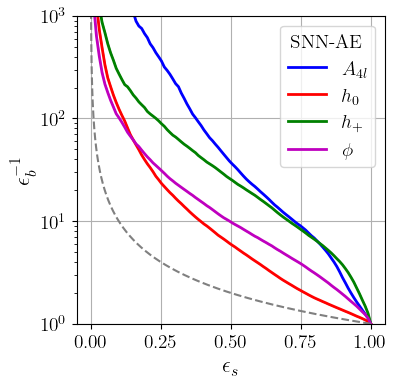

In [7]:
net = full_snn_run( 'results/SNNAE-24-12-4-LR001-100k-T20-B09-TH12', 19, 0.9, 1.2, 20, [24,12], 4, 0.001, 400, False, 8, 3 )